
# Business Problem
A news agency receives thousands of articles every day.
The company wants an AI system that:
Reads news articles
Understands important words using Self-Attention
Classifies article category
Shows which words influenced the prediction
 
Task 1: Data Exploration
Students must answer:
Questions
Total articles?
Number of categories?
Category distribution?
Average article length?
Longest article?
Shortest article?
Visualizations
Count Plot
Pie Chart
Histogram
 
Task 2: Text Preprocessing
Perform:
Lower Case
Remove Punctuation
Remove Special Characters
Tokenization
Padding
Task 3: Label Encoding
Convert:
Business → 0
Politics → 1
Sport → 2
Tech → 3
Entertainment → 4
 
Task 4: Baseline Model
Build:
Embedding
↓
LSTM
↓
Dense
↓
Classification
Record:
Accuracy
Loss
Training Time
 
Task 5: Self-Attention Model
Build:
Input
↓
Embedding
↓
MultiHeadAttention
↓
GlobalAveragePooling1D
↓
Dense
↓
Output
 
Task 6: Compare Models
Compare:
Metric	LSTM	Self-Attention
Accuracy	?	?
Loss	?	?
Training Time	?	?
Students must explain:
Why Self-Attention performs better?
 
Task 7: Extract Attention Scores
This is the MOST IMPORTANT task.
Example News:
Apple launches new AI-powered iPhone.
Attention Output:
Apple       0.42
AI          0.35
iPhone      0.18
launches    0.05
Students should identify:
Which words received highest attention?
 
Task 8: Attention Heatmap
Display:
sns.heatmap()
Example:
Apple  → AI
AI     → iPhone
iPhone → Apple
Students finally see:
Word-to-Word Relationships
which is the essence of Self-Attention.
 
Task 9: Save Model
Save:
model.h5
tokenizer.pkl
label_encoder.pkl
 

https://www.kaggle.com/datasets/yufengdev/bbc-fulltext-and-category
BBC articles fulltext and category | Kaggle
Title, body, and category of over 2 thousand BBC full text articles. 
 

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yufengdev/bbc-fulltext-and-category")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bbc-fulltext-and-category' dataset.
Path to dataset files: /kaggle/input/bbc-fulltext-and-category


In [2]:
import pandas as pd
import os

os.listdir(path)

['bbc-text.csv']

In [3]:
csv_file=os.path.join(path,"bbc-text.csv")
df=pd.read_csv(csv_file)

print(df.head())

        category                                               text
0           tech  tv future in the hands of viewers with home th...
1       business  worldcom boss  left books alone  former worldc...
2          sport  tigers wary of farrell  gamble  leicester say ...
3          sport  yeading face newcastle in fa cup premiership s...
4  entertainment  ocean s twelve raids box office ocean s twelve...


In [4]:
print(df.shape)
print(df.columns)

(2225, 2)
Index(['category', 'text'], dtype='object')


In [5]:
total_articles = len(df)

print("Total articles:", total_articles)

Total articles: 2225


In [6]:
print("Number of Categories:", df['category'].nunique())

Number of Categories: 5


In [7]:
print(df['category'].value_counts())

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [8]:
df['article_length'] = df['text'].apply(
    lambda x: len(str(x).split())
)

print("Average Length:",
      round(df['article_length'].mean(),2))

Average Length: 390.3


In [9]:
print("Longest Article Length:",
      df['article_length'].max())

Longest Article Length: 4492


In [10]:
print("Longest Article Length:",
      df['article_length'].max())

Longest Article Length: 4492


In [11]:
print("Shortest Article Length:",
      df['article_length'].min())

Shortest Article Length: 90


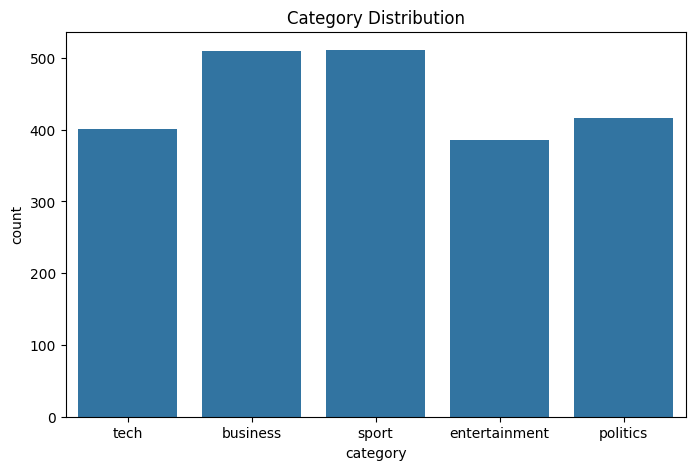

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='category'
)

plt.title("Category Distribution")
plt.show()

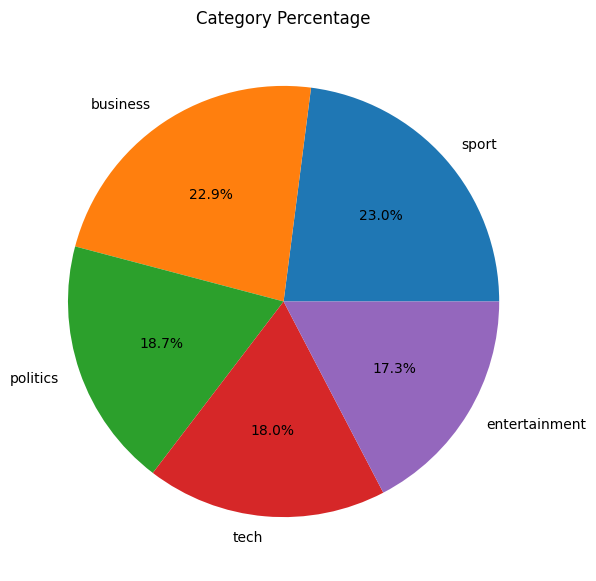

In [13]:
df['category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Category Percentage")
plt.ylabel("")
plt.show()

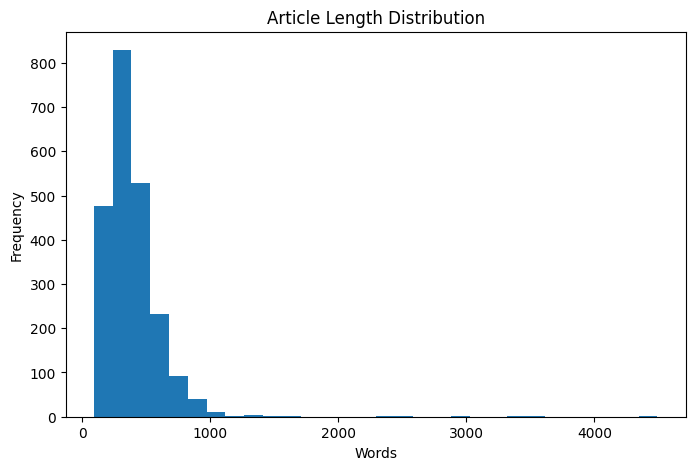

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    df['article_length'],
    bins=30
)

plt.title("Article Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

# Task2- Text Processing

In [15]:
#lower case
df['clean_text'] = df['text'].str.lower()

In [16]:
print(df.columns)

Index(['category', 'text', 'article_length', 'clean_text'], dtype='object')


In [17]:
#Remove Punctuation
import string

df['clean_text'] = df['clean_text'].str.translate(
    str.maketrans('', '', string.punctuation)
)

In [18]:
#Remove Special Characters
import re

df['clean_text'] = df['clean_text'].apply(
    lambda x: re.sub(r'[^a-zA-Z ]', '', x)
)

In [19]:
print(df[['text', 'clean_text']].head())

                                                text  \
0  tv future in the hands of viewers with home th...   
1  worldcom boss  left books alone  former worldc...   
2  tigers wary of farrell  gamble  leicester say ...   
3  yeading face newcastle in fa cup premiership s...   
4  ocean s twelve raids box office ocean s twelve...   

                                          clean_text  
0  tv future in the hands of viewers with home th...  
1  worldcom boss  left books alone  former worldc...  
2  tigers wary of farrell  gamble  leicester say ...  
3  yeading face newcastle in fa cup premiership s...  
4  ocean s twelve raids box office ocean s twelve...  


In [20]:
#Tokenization
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])

print("Vocabulary Size:", len(tokenizer.word_index))

Vocabulary Size: 30340


In [21]:
#Padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 200

X = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post'
)

print(X.shape)

(2225, 200)


In [22]:
print(df['category'].unique())

['tech' 'business' 'sport' 'entertainment' 'politics']


# Task 3: Label Encoding

In [23]:
label_map = {
    'business': 0,
    'politics': 1,
    'sport': 2,
    'tech': 3,
    'entertainment': 4
}

y = df['category'].map(label_map)

print(y.head())
print(y.shape)

0    3
1    0
2    2
3    2
4    4
Name: category, dtype: int64
(2225,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1780, 200)
(445, 200)


# Task 4: Baseline Model


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential([
    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=200
    ),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(5, activation='softmax')
])

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
import time

start_time = time.time()

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

lstm_training_time = time.time() - start_time

print("Training Time:", round(lstm_training_time, 2), "seconds")

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.2798 - loss: 1.5205 - val_accuracy: 0.3798 - val_loss: 1.3925
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4079 - loss: 1.3290 - val_accuracy: 0.4022 - val_loss: 1.2689
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5062 - loss: 1.1496 - val_accuracy: 0.5506 - val_loss: 1.1113
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6871 - loss: 0.9021 - val_accuracy: 0.7213 - val_loss: 0.9813
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8309 - loss: 0.5550 - val_accuracy: 0.7865 - val_loss: 0.7177
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9169 - loss: 0.2767 - val_accuracy: 0.8000 - val_loss: 0.6160
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9449 - loss: 0.1487 - val_accuracy: 0.8360 - val_loss: 0.5668
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9725 - loss: 0.0965 - val_accuracy: 0.8427 - v

In [28]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9489 - loss: 0.1707 - val_accuracy: 0.8427 - val_loss: 0.5678
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9652 - loss: 0.1809 - val_accuracy: 0.8225 - val_loss: 0.6484
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9618 - loss: 0.1757 - val_accuracy: 0.8022 - val_loss: 0.6347
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9871 - loss: 0.0675 - val_accuracy: 0.8360 - val_loss: 0.6110
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9899 - loss: 0.0436 - val_accuracy: 0.8382 - val_loss: 0.6350


In [29]:
print(X_train.shape)
print(y_train.shape)
print(y_train[:5])

(1780, 200)
(1780,)
1490    4
2001    0
1572    0
1840    4
610     3
Name: category, dtype: int64


In [30]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test,
    y_test
)

print("LSTM Accuracy:", lstm_acc)
print("LSTM Loss:", lstm_loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8382 - loss: 0.6350
LSTM Accuracy: 0.8382022380828857
LSTM Loss: 0.6349513530731201


In [31]:
lstm_training_time = time.time() - start_time

print("LSTM Training Time:", round(lstm_training_time, 2), "seconds")

LSTM Training Time: 19.81 seconds


In [32]:
from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

# Task 5: Self-Attention Model

Build:
Input
↓
Embedding
↓
MultiHeadAttention
↓
GlobalAveragePooling1D
↓
Dense
↓
Output

In [33]:
inputs = Input(shape=(200,))

In [34]:
embedding = Embedding(
    input_dim=10000,
    output_dim=128
)(inputs)

In [35]:
attention_layer = MultiHeadAttention(
    num_heads=2,
    key_dim=64
)
attention_output, attention_scores = attention_layer(
    embedding,
    embedding,
    return_attention_scores=True
)

In [36]:
pooled = GlobalAveragePooling1D()(attention_output)

In [37]:
dense = Dense(64, activation='relu')(pooled)
dropout = Dropout(0.3)(dense)

In [38]:
outputs = Dense(
    5,
    activation='softmax'
)(dropout)

In [39]:
attention_model = Model(
    inputs,
    outputs
)

attention_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 128)  │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 200,      │     66,048 │ embedding_1[0][0… │
│ (MultiHeadAttentio… │ 128), (None, 2,   │            │ embedding_1[0][0] │
│                     │ 200, 200)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        325 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,354,629 (5.17 MB)

 Trainable params: 1,354,629 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf.fit(df['clean_text'])

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

In [41]:
attention_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
import time

start_time = time.time()

history_attention = attention_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

attention_training_time = time.time() - start_time

Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.3618 - loss: 1.4733 - val_accuracy: 0.6562 - val_loss: 1.0026
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9045 - loss: 0.3724 - val_accuracy: 0.9124 - val_loss: 0.2865
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9837 - loss: 0.0607 - val_accuracy: 0.9258 - val_loss: 0.2757
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9949 - loss: 0.0240 - val_accuracy: 0.9236 - val_loss: 0.3168
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9978 - loss: 0.0112 - val_accuracy: 0.9191 - val_loss: 0.3501


In [43]:
attention_loss, attention_acc = attention_model.evaluate(
    X_test,
    y_test
)

print("Attention Accuracy:", attention_acc)
print("Attention Loss:", attention_loss)

print("Attention Training Time:",
      round(attention_training_time, 2),
      "seconds")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9191 - loss: 0.3501 
Attention Accuracy: 0.9191011190414429
Attention Loss: 0.3501055836677551
Attention Training Time: 11.23 seconds


# Task 6: Compare Models

In [44]:
comparison = {
    "Metric": ["Accuracy", "Loss", "Training Time"],
    "LSTM": [
        lstm_acc,
        lstm_loss,
        lstm_training_time
    ],
    "Self-Attention": [
        attention_acc,
        attention_loss,
        attention_training_time
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

print(comparison_df)

          Metric       LSTM  Self-Attention
0       Accuracy   0.838202        0.919101
1           Loss   0.634951        0.350106
2  Training Time  19.808808       11.231946


# Task 7: Extract Attention Scores

In [45]:
attention_output, attention_scores = attention_layer(
    embedding,
    embedding,
    return_attention_scores=True
)

In [46]:
attention_output, attention_scores = attention_layer(
    embedding,
    embedding,
    return_attention_scores=True
)

In [47]:
reverse_word_index = {
    v:k for k,v in tokenizer.word_index.items()
}

tokens = X_test[0][:20]

words = []

for token in tokens:
    words.append(
        reverse_word_index.get(token, "")
    )

print(words)

['on', 'the', 'both', 'men', 'separately', 'spoke', 'about', 'working', 'on', 'tsunami', 'or', 'wider', 'aid', 'and', 'development', 'policy', 'with', 'their', 'cabinet', 'colleagues']


In [48]:
attention_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 128)  │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 200,      │     66,048 │ embedding_1[0][0… │
│ (MultiHeadAttentio… │ 128), (None, 2,   │            │ embedding_1[0][0] │
│                     │ 200, 200)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        325 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,063,889 (15.50 MB)

 Trainable params: 1,354,629 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,709,260 (10.34 MB)

In [49]:
print(attention_model.layers)

[<InputLayer name=input_layer_1, built=True>, <Embedding name=embedding_1, built=True>, <MultiHeadAttention name=multi_head_attention, built=True>, <GlobalAveragePooling1D name=global_average_pooling1d, built=True>, <Dense name=dense_2, built=True>, <Dropout name=dropout_1, built=True>, <Dense name=dense_3, built=True>]


In [ ]:
attention_layer = attention_model.get_layer(
    "multi_head_attention"
)

print(attention_layer)

ValueError: No such layer: multi_head_attention_6. Existing layers are: ['input_layer_1', 'embedding_1', 'multi_head_attention', 'global_average_pooling1d', 'dense_2', 'dropout_1', 'dense_3'].

In [ ]:
print(attention_scores)

In [ ]:
from tensorflow.keras.models import Model

attention_extractor = Model(
    inputs=attention_model.input,
    outputs=attention_scores
)

In [ ]:
sample = X_test[0:1]

scores = attention_extractor.predict(sample)

print(scores.shape)

In [ ]:
head1 = scores[0][0]

print(head1.shape)

# Task8 : Attention heatmap

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    head1[:20,:20]
)

plt.title("Attention Heatmap")

plt.show()

In [ ]:
reverse_word_index = {
    v:k for k,v in tokenizer.word_index.items()
}

tokens = X_test[0][:20]

words = [
    reverse_word_index.get(token, "")
    for token in tokens
]

print(words)

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    head1[:20,:20],
    xticklabels=words,
    yticklabels=words
)

plt.title("Word-to-Word Attention")

plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf.fit(df['clean_text'])

# Task 9: Save Model

In [ ]:
attention_model.save("model.h5")

In [ ]:
import pickle

with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

In [ ]:
import pickle

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

In [ ]:
label_map = {
    'business':0,
    'politics':1,
    'sport':2,
    'tech':3,
    'entertainment':4
}

with open("label_map.pkl","wb") as f:
    pickle.dump(label_map,f)

In [ ]:
import os

print(os.listdir())